<a href="https://colab.research.google.com/github/yumoylmz/food-waste-analysis-ml-prediction/blob/main/food_waste_analysis_ml_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df=pd.read_csv('food_wastage.csv')

In [98]:
df.head()

,Country,Year,Food Category,Total Waste (Tons),Economic Loss (Million $),Avg Waste per Capita (Kg),Population (Million),Household Waste (%)
0,Australia,2019,Fruits & Vegetables,19268.63,18686.68,72.69,87.59,53.64
1,Indonesia,2019,Prepared Food,3916.97,4394.48,192.52,1153.99,30.61
2,Germany,2022,Dairy Products,9700.16,8909.16,166.94,1006.11,48.08
3,France,2023,Fruits & Vegetables,46299.69,40551.22,120.19,953.05,31.91
4,France,2023,Beverages,33096.57,36980.82,104.74,1105.47,36.06


In [99]:
df.shape

(5000, 8)

In [100]:
df.rename(columns={'Total Waste (Tons)': 'Total Waste'}, inplace=True)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    5000 non-null   object 
 1   Year                       5000 non-null   int64  
 2   Food Category              5000 non-null   object 
 3   Total Waste                5000 non-null   float64
 4   Economic Loss (Million $)  5000 non-null   float64
 5   Avg Waste per Capita (Kg)  5000 non-null   float64
 6   Population (Million)       5000 non-null   float64
 7   Household Waste (%)        5000 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 312.6+ KB


In [102]:
df.isnull().sum()

,0
Country,0
Year,0
Food Category,0
Total Waste,0
Economic Loss (Million $),0
Avg Waste per Capita (Kg),0
Population (Million),0
Household Waste (%),0


In [103]:
df.describe()

,Year,Total Waste,Economic Loss (Million $),Avg Waste per Capita (Kg),Population (Million),Household Waste (%)
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2021.015600,25061.780072,25039.703870,109.46397,706.606416,50.060890
std,1.999239,14245.119588,14620.236429,51.93373,402.546464,11.596203
min,2018.000000,502.610000,406.690000,20.09000,11.290000,30.020000
25%,2019.000000,12783.737500,12612.477500,64.05000,350.602500,40.012500
50%,2021.000000,24865.220000,24428.155000,110.08000,713.530000,50.295000
75%,2023.000000,37471.035000,37146.037500,154.52500,1057.255000,60.125000
max,2024.000000,49990.760000,59228.930000,199.97000,1399.970000,70.000000


In [104]:
df['Country'].unique()

array(['Australia', 'Indonesia', 'Germany', 'France', 'India', 'China',
       'UK', 'South Africa', 'Japan', 'USA', 'Brazil', 'Saudi Arabia',
       'Italy', 'Spain', 'Mexico', 'Argentina', 'Canada', 'South Korea',
       'Russia', 'Turkey'], dtype=object)

In [105]:
df['Food Category'].unique()

array(['Fruits & Vegetables', 'Prepared Food', 'Dairy Products',
       'Beverages', 'Meat & Seafood', 'Grains & Cereals', 'Frozen Food',
       'Bakery Items'], dtype=object)

In [107]:
grouped = df.groupby('Food Category')['Economic Loss (Million $)'].sum()

print(grouped)

Food Category
Bakery Items           15536973.93
Beverages              16331179.83
Dairy Products         15223458.70
Frozen Food            15180582.95
Fruits & Vegetables    15622033.18
Grains & Cereals       14073418.43
Meat & Seafood         15352228.39
Prepared Food          17878643.94
Name: Economic Loss (Million $), dtype: float64


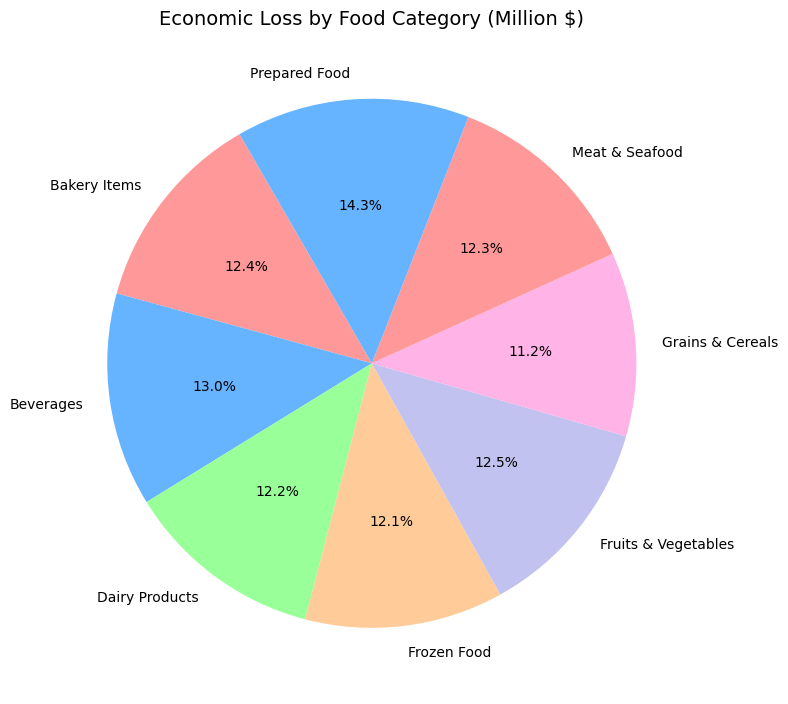

In [118]:
# Pie chart
plt.figure(figsize=(8, 8))
grouped.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6'], startangle=120)
plt.title('Economic Loss by Food Category (Million $)',fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

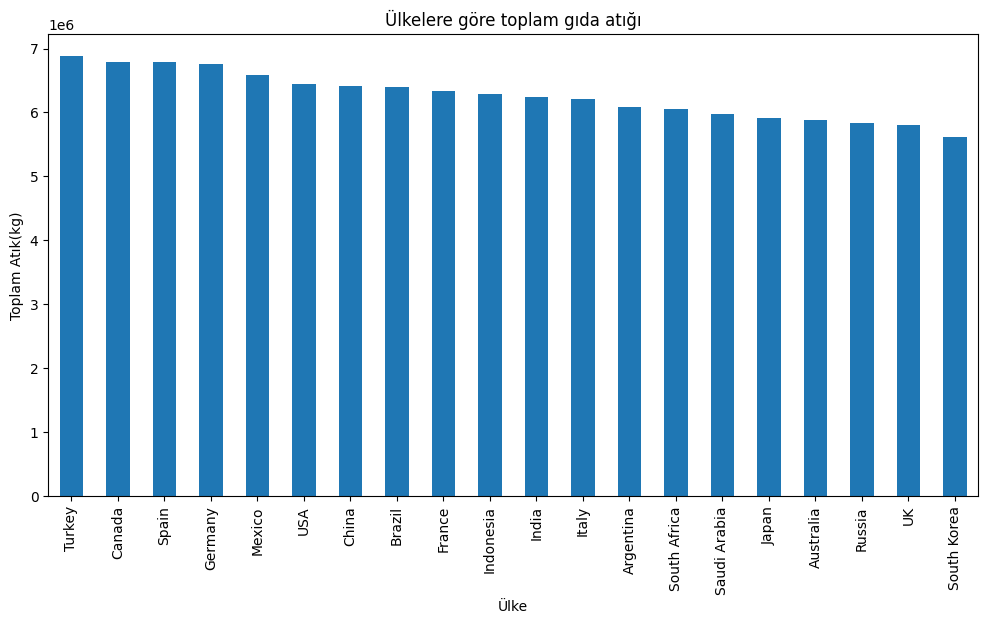

In [10]:
# Ülkelere göre toplam atık miktarı
country_waste=df.groupby('Country')['Total Waste'].sum().sort_values(ascending=False)
country_waste.plot(kind='bar',figsize=(12,6))
plt.title('Ülkelere göre toplam gıda atığı')
plt.ylabel('Toplam Atık(kg)')
plt.xlabel('Ülke')
plt.show()

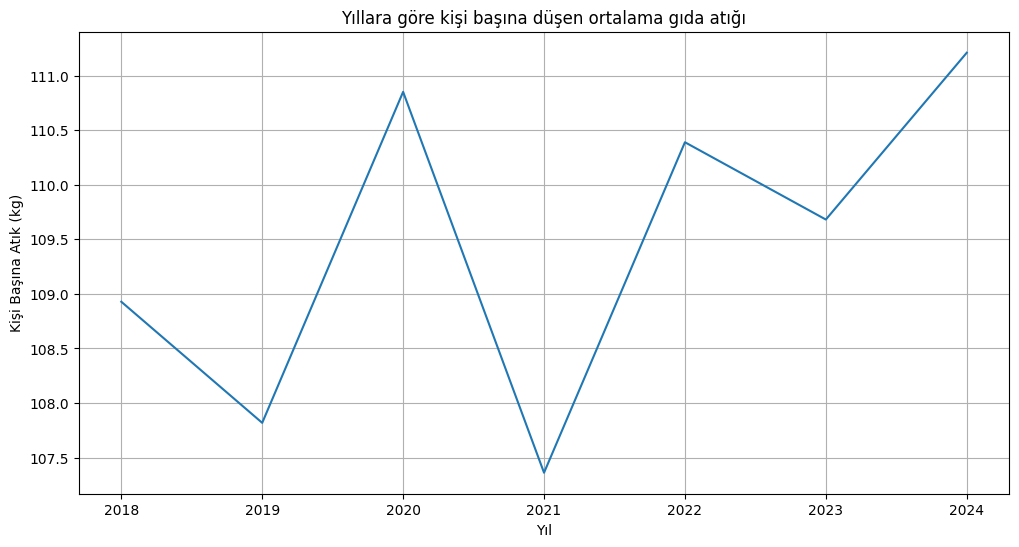

In [11]:
#Yıllara göre kişi başına düşen ortalama atık miktarı
yearly_waste=df.groupby('Year')['Avg Waste per Capita (Kg)'].mean()
yearly_waste.plot(kind='line',figsize=(12,6))
plt.title('Yıllara göre kişi başına düşen ortalama gıda atığı')
plt.ylabel('Kişi Başına Atık (kg)')
plt.xlabel('Yıl')
plt.grid(True)
plt.show()

In [12]:
df = pd.get_dummies(df, columns=['Food Category','Country'], drop_first= True)

In [14]:
df.head()

,Year,Total Waste,Economic Loss (Million $),Avg Waste per Capita (Kg),Population (Million),Household Waste (%),Food Category_Beverages,Food Category_Dairy Products,Food Category_Frozen Food,Food Category_Fruits & Vegetables,...,Country_Japan,Country_Mexico,Country_Russia,Country_Saudi Arabia,Country_South Africa,Country_South Korea,Country_Spain,Country_Turkey,Country_UK,Country_USA
0,2019,19268.63,18686.68,72.69,87.59,53.64,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,2019,3916.97,4394.48,192.52,1153.99,30.61,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022,9700.16,8909.16,166.94,1006.11,48.08,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2023,46299.69,40551.22,120.19,953.05,31.91,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2023,33096.57,36980.82,104.74,1105.47,36.06,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
# Veri setini train ve test olarak ayıralım (80-20)
x=df.drop(columns='Avg Waste per Capita (Kg)')
y=df['Avg Waste per Capita (Kg)']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 31)
(1000, 31)
(4000,)
(1000,)


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [89]:
# modeli oluştur
model = RandomForestRegressor(n_estimators=50, max_depth=10, min_samples_split=2)
# modeli eğit
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

# Modelin başarımını değerlendirelim
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

2451.7842442274623
11102872.923781686
11102872.923781686
0.9473844476017829


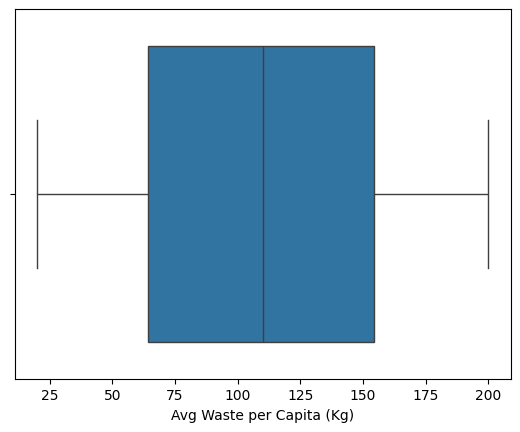

In [20]:
sns.boxplot(x=df['Avg Waste per Capita (Kg)'])
plt.show()

In [30]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [28]:
x=df.drop(columns='Economic Loss (Million $)')
y=df['Economic Loss (Million $)']

In [58]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100)

In [56]:
# Modeli oluştur ve eğit
model = XGBRegressor()
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [57]:
# Test verisi üzerindeki doğruluk (R² skoru)
score = model.score(x_test, y_test)
print("R² Skoru:", score)

R² Skoru: 0.9358024151989368


In [67]:
y_pred = model.predict(x_test)
print(y_pred)

[36923.492   10131.125   22835.201    1057.7853  33342.844   36939.27
 23899.457   47084.645   21144.572    2881.295   11851.017    7549.547
 29998.355   46918.35     9961.839   44250.344   38547.438   40549.22
 14272.85    39261.816   12250.505   27907.344   38662.14    18073.775
  7244.963    5636.0063  36522.47    33818.312   52631.2     12756.663
  2611.6458  42640.145   30850.055   45880.613    5592.7275  12802.209
  2143.0476  11133.369    5700.151   26041.068    9548.597   35544.29
 11988.789    1495.4935  25280.902   41954.234   39870.33     1272.365
 25416.613   38472.453   13967.748   28494.518    1575.383   46354.527
  4880.564   11795.376   10558.973   43144.957    4239.992   22114.748
 39768.402   29453.797   26566.27    48491.71    38993.254   26963.076
 46415.066   13480.843    4131.8384  39980.562   50313.047   45914.75
 39457.086   20587.682    1915.3644  21136.584   40762.082   41535.14
 18247.664   19200.273    1662.9183  25879.78    25757.295    3213.9324
 14404.675

In [72]:
correlation = df['Economic Loss (Million $)'].corr(df['Total Waste'])
print("correlation",correlation)

correlation 0.9745219286512476


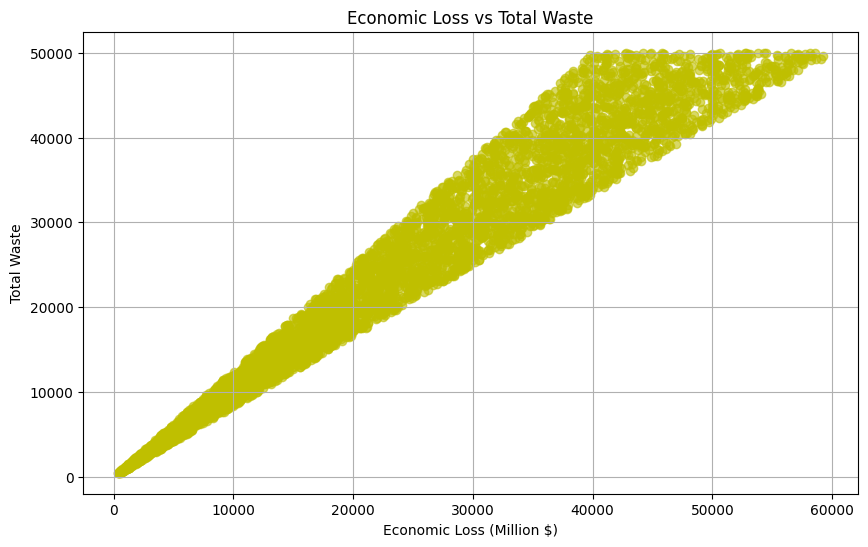

In [88]:
import matplotlib.pyplot as plt

# Scatter plot çizme
plt.figure(figsize=(10, 6))
plt.scatter(df['Economic Loss (Million $)'], df['Total Waste'], alpha=0.6, color='y')
plt.title('Economic Loss vs Total Waste')
plt.xlabel('Economic Loss (Million $)')
plt.ylabel('Total Waste')
plt.grid(True)
plt.show()
